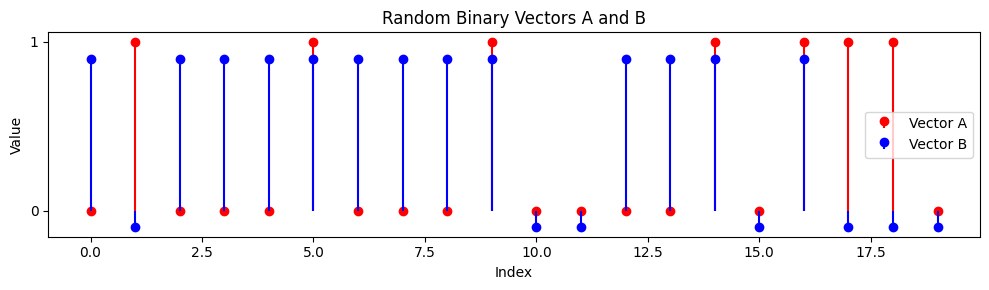

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate two random binary arrays of length N
N = 20
a = np.random.randint(0, 2, N)
b = np.random.randint(0, 2, N)

# Plot the two binary arrays
fig, ax = plt.subplots(figsize=(10, 3))

# Plot vector A
ax.stem(range(N), a, linefmt='r-', markerfmt='ro', basefmt=' ', label='Vector A')

# Plot vector B (slightly shifted for visibility)
ax.stem(range(N), b - 0.1, linefmt='b-', markerfmt='bo', basefmt=' ', label='Vector B')

# Formatting
ax.set_yticks([0, 1])
ax.set_xlabel("Index")
ax.set_ylabel("Value")
ax.set_title("Random Binary Vectors A and B")
ax.legend()
plt.tight_layout()
plt.show()


In [9]:
import yaml

with open("config.yaml") as f:
    config = yaml.safe_load(f)

configs = config["configs"]

# ✅ Indexing like a list
print(configs[0])         # {'term': 'short'}
print(configs[1])         # {'domain': 'Energy', 'term': 'medium'}

# ✅ Looping over the configs
for i, entry in enumerate(configs):
    print(f"Config {i}: {entry}")


{'term': 'short'}
{'term': 'medium'}
Config 0: {'term': 'short'}
Config 1: {'term': 'medium'}
Config 2: {'term': 'long'}
Config 3: {'domain': 'Energy', 'term': 'short'}
Config 4: {'domain': ['Climate', 'Nature'], 'term': 'long'}


In [10]:
import csv
import yaml

def parse_row(columns, values):
    keys = columns.split(";")
    vals = values.split(";")

    result = {}
    for k, v in zip(keys, vals):
        if "," in v:
            result[k] = v.split(",")  # multi-value field → list
        else:
            result[k] = v
    return result

csv_path = "resources/train_test/dataset_configs.csv"
yaml_path = "foo.yaml"

configs = []

with open(csv_path, newline="") as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        config = parse_row(row["columns"], row["values"])
        configs.append(config)

# Wrap into a top-level key if needed
yaml_dict = {"configs": configs}

with open(yaml_path, "w") as f:
    yaml.dump(yaml_dict, f, sort_keys=False)


In [11]:

with open("foo.yaml") as f:
    config = yaml.safe_load(f)

configs = config["configs"]

# ✅ Indexing like a list
print(configs[0])         # {'term': 'short'}
print(configs[1])         # {'domain': 'Energy', 'term': 'medium'}

# ✅ Looping over the configs
for i, entry in enumerate(configs):
    print(f"Config {i}: {entry}")

{'term': 'short'}
{'term': 'medium'}
Config 0: {'term': 'short'}
Config 1: {'term': 'medium'}
Config 2: {'term': 'long'}
Config 3: {'domain,term': ['Transport', 'short']}
Config 4: {'domain,term': ['Web/CloudOps', 'short']}
Config 5: {'domain,term': ['Sales', 'short']}
Config 6: {'domain,term': ['Healthcare', 'short']}
Config 7: {'domain,term': ['Energy', 'short']}
Config 8: {'domain,term': ['Nature', 'short']}
Config 9: {'domain,term': ['Econ/Fin', 'short']}
Config 10: {'domain,term': ['Transport', 'medium']}
Config 11: {'domain,term': ['Web/CloudOps', 'medium']}
Config 12: {'domain,term': ['Energy', 'medium']}
Config 13: {'domain,term': ['Nature', 'medium']}
Config 14: {'domain,term': ['Transport', 'long']}
Config 15: {'domain,term': ['Web/CloudOps', 'long']}
Config 16: {'domain,term': ['Energy', 'long']}
Config 17: {'domain,term': ['Nature', 'long']}
Config 18: {'name,term': ['LOOP_SEATTLE/5T', 'short']}
Config 19: {'name,term': ['LOOP_SEATTLE/D', 'short']}
Config 20: {'name,term': 